# Cross-Species Generalization & Speed Benchmark — 4L Pure Transformer (KD)

Evaluates the best pure-architecture student (**4L-Pure-Transformer + KD**, 93.01%, 32.5M params) against the **DNABERT-2 teacher** (96.71%, 117.1M params) on:

1. **Human promoters** (verification on test set)
2. **Mouse promoters** (same kingdom — Mammalia, DeePromoter/CNNPromoterData)
3. **Plant promoters** (different kingdom — Plantae, 13 species, zhangtaolab HuggingFace)
4. **Inference speed** (GPU & CPU, ms per 1000 sequences)
5. **Model size comparison**

**Setup:** Add BOTH notebook outputs as Kaggle inputs:
- Teacher notebook (ml-project-kaggle) — for DNABERT-2 checkpoint
- Pure architecture notebook (pure-architectures-baseline-and-kd) — for 4L-Pure-Transformer_kd model

GPU T4 x 2, Internet ON.

In [1]:
!pip install transformers datasets accelerate scikit-learn einops

# Configuration & Imports

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
import gc
import os
import json
import time
from transformers import (
    AutoTokenizer, AutoConfig, BertConfig, BertForSequenceClassification,
)
from transformers.modeling_outputs import SequenceClassifierOutput
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

MODEL_NAME = "quietflamingo/dnabert2-no-flashattention"
MAX_LENGTH = 300
SEED = 42

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
num_gpus = torch.cuda.device_count()
print(f"Device: {device}, GPUs: {num_gpus}")
for i in range(num_gpus):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)} ({torch.cuda.get_device_properties(i).total_memory/1e9:.1f} GB)")

Device: cuda, GPUs: 2
  GPU 0: Tesla T4 (15.6 GB)
  GPU 1: Tesla T4 (15.6 GB)


# Load Human Dataset & Tokenize

In [3]:
print("Loading human promoter dataset...")
raw_dataset = load_dataset("InstaDeepAI/nucleotide_transformer_downstream_tasks")
train_data_raw = raw_dataset["train"].filter(lambda x: x["task"] == "promoter_all")
test_data_raw = raw_dataset["test"].filter(lambda x: x["task"] == "promoter_all")
train_data = train_data_raw.map(lambda x: {"sequence": x["sequence"].upper(), "label": int(x["label"])})
test_data = test_data_raw.map(lambda x: {"sequence": x["sequence"].upper(), "label": int(x["label"])})
print(f"Train: {len(train_data)}, Test: {len(test_data)}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

def tokenize_func(examples):
    return tokenizer(examples["sequence"], padding="max_length", truncation=True, max_length=MAX_LENGTH)

tokenized_train = train_data.map(tokenize_func, batched=True)
tokenized_test = test_data.map(tokenize_func, batched=True)
tokenized_train.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
tokenized_test.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_test = tokenized_test.rename_column("label", "labels")
eval_dataset = tokenized_test
VOCAB_SIZE = tokenizer.vocab_size
print(f"Vocab: {VOCAB_SIZE}, Test samples: {len(eval_dataset)}")

Loading human promoter dataset...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

H3/train.parquet:   0%|          | 0.00/3.48M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/158 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/53276 [00:00<?, ? examples/s]

Map:   0%|          | 0/5920 [00:00<?, ? examples/s]

Vocab: 4096, Test samples: 5920


# Load Teacher & Best Student Models

In [4]:
import glob
from safetensors.torch import load_file as load_safetensors
from transformers.dynamic_module_utils import get_class_from_dynamic_module

# ===== LOAD TEACHER (DNABERT-2) =====
def find_teacher_model():
    base = "/kaggle/input"
    for filename in ["model.safetensors", "pytorch_model.bin"]:
        matches = glob.glob(f"{base}/**/lr_2e-05_results/checkpoint-4375/{filename}", recursive=True)
        if matches:
            return os.path.dirname(matches[0]), "best checkpoint (96.71%)"
    for filename in ["model.safetensors", "pytorch_model.bin"]:
        matches = glob.glob(f"{base}/**/human_promoter_model/{filename}", recursive=True)
        if matches:
            return os.path.dirname(matches[0]), "Phase 1 model (96.40%)"
    return None, None

teacher_path, teacher_desc = find_teacher_model()
if teacher_path is None:
    raise FileNotFoundError("Teacher not found! Add teacher notebook output as Kaggle input.")
print(f"Teacher: {teacher_desc}\nPath: {teacher_path}")

config = AutoConfig.from_pretrained(MODEL_NAME, trust_remote_code=True)
config.num_labels = 2
config.pad_token_id = tokenizer.pad_token_id
class_ref = config.auto_map["AutoModelForSequenceClassification"]
model_class = get_class_from_dynamic_module(class_ref, MODEL_NAME)
teacher_model = model_class(config)

weights_file = os.path.join(teacher_path, "model.safetensors")
if os.path.exists(weights_file):
    state_dict = load_safetensors(weights_file)
else:
    weights_file = os.path.join(teacher_path, "pytorch_model.bin")
    state_dict = torch.load(weights_file, map_location="cpu", weights_only=True)
teacher_model.load_state_dict(state_dict)
teacher_model.eval()
teacher_model.to(device)
teacher_params = sum(p.numel() for p in teacher_model.parameters())
print(f"Teacher loaded: {teacher_params:,} ({teacher_params/1e6:.1f}M)")

# ===== LOAD 4L-PURE-TRANSFORMER (KD) =====
# Search for the saved model from pure architecture notebook output
student_search = glob.glob("/kaggle/input/**/4L-Pure-Transformer_kd_final/**/*.safetensors", recursive=True)
if not student_search:
    student_search = glob.glob("/kaggle/input/**/4L-Pure-Transformer_kd_final/**/*.bin", recursive=True)
if not student_search:
    # Fallback: search checkpoint directory
    student_search = glob.glob("/kaggle/input/**/4L-Pure-Transformer_kd/checkpoint-*/model.safetensors", recursive=True)

print(f"\nStudent .safetensors/.bin found: {student_search}")

# Also list input directories for debugging
print("\n/kaggle/input/ contents:")
for item in os.listdir("/kaggle/input/"):
    print(f"  {item}/")
    subpath = os.path.join("/kaggle/input", item)
    if os.path.isdir(subpath):
        for sub in sorted(os.listdir(subpath))[:15]:
            print(f"    {sub}")

# Load student: standard BERT (not DNABERT-2) with 4 layers
student_config = BertConfig(
    vocab_size=VOCAB_SIZE,
    hidden_size=768,
    num_hidden_layers=4,
    num_attention_heads=12,
    intermediate_size=3072,
    max_position_embeddings=512,
    num_labels=2,
)

if student_search:
    student_dir = os.path.dirname(student_search[0])
    student_model = BertForSequenceClassification.from_pretrained(student_dir, config=student_config)
    print(f"\nLoaded 4L-Pure-Transformer (KD) from: {student_dir}")
else:
    print("\nWARNING: Student model not found! Using random weights.")
    student_model = BertForSequenceClassification(student_config)

student_model.eval()
student_model.to(device)
student_params = sum(p.numel() for p in student_model.parameters())
print(f"Student loaded: {student_params:,} ({student_params/1e6:.1f}M)")

# ===== QUICK VERIFICATION ON HUMAN TEST SET =====
from torch.utils.data import DataLoader

eval_loader = DataLoader(eval_dataset, batch_size=32, shuffle=False)

def quick_eval(model, loader, model_name):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"]
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = outputs.logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    print(f"  {model_name:<30} Accuracy: {acc:.2%}  F1: {f1:.4f}")
    return acc, f1

print(f"\n{'='*60}")
print("VERIFICATION ON HUMAN TEST SET")
print(f"{'='*60}")
teacher_human_acc, teacher_human_f1 = quick_eval(teacher_model, eval_loader, "Teacher (DNABERT-2)")
student_human_acc, student_human_f1 = quick_eval(student_model, eval_loader, "4L-Pure-Transformer (KD)")

Teacher: best checkpoint (96.71%)
Path: /kaggle/input/notebooks/sheikhrahatmahmud/ml-project-kaggle15916a635e/lr_2e-05_results/checkpoint-4375


bert_layers.py: 0.00B [00:00, ?B/s]

bert_padding.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/quietflamingo/dnabert2-no-flashattention:
- bert_padding.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/quietflamingo/dnabert2-no-flashattention:
- bert_layers.py
- bert_padding.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/root/.cache/huggingface/modules/transformers_modules/quietflamingo/dnabert2_hyphen_no_hyphen_flashattention/813031b2bf86d9e960a027e2734c908009f31601/bert_layers.py:123: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


Teacher loaded: 117,070,082 (117.1M)

Student .safetensors/.bin found: ['/kaggle/input/notebooks/sheikhrahatmahmud/pure-architecture-for-distillation/4L-Pure-Transformer_kd_final/model.safetensors']

/kaggle/input/ contents:
  notebooks/
    sheikhrahatmahmud


Loading weights:   0%|          | 0/73 [00:00<?, ?it/s]


Loaded 4L-Pure-Transformer (KD) from: /kaggle/input/notebooks/sheikhrahatmahmud/pure-architecture-for-distillation/4L-Pure-Transformer_kd_final
Student loaded: 32,485,634 (32.5M)

VERIFICATION ON HUMAN TEST SET
  Teacher (DNABERT-2)            Accuracy: 96.71%  F1: 0.9670
  4L-Pure-Transformer (KD)       Accuracy: 93.01%  F1: 0.9284


# Cross-Species Generalization: Mouse & Plant Promoters

In [5]:
import urllib.request
from torch.utils.data import TensorDataset, DataLoader
from collections import Counter

# ===== DOWNLOAD MOUSE PROMOTER DATA =====
MOUSE_FILES = {
    "Mouse_tata.fa": "https://raw.githubusercontent.com/solovictor/CNNPromoterData/master/Mouse_tata.fa",
    "Mouse_non_tata.fa": "https://raw.githubusercontent.com/solovictor/CNNPromoterData/master/Mouse_non_tata.fa",
    "Mouse_nonprom.fa": "https://raw.githubusercontent.com/solovictor/CNNPromoterData/master/Mouse_nonprom.fa",
}
mouse_dir = "/kaggle/working/mouse_data"
os.makedirs(mouse_dir, exist_ok=True)
for fname, url in MOUSE_FILES.items():
    fpath = os.path.join(mouse_dir, fname)
    if not os.path.exists(fpath):
        print(f"Downloading {fname}...")
        urllib.request.urlretrieve(url, fpath)
    else:
        print(f"Already have {fname}")

# ===== LOAD PLANT DATASET =====
print("\nLoading plant multi-species promoter dataset...")
plant_dataset_raw = load_dataset("zhangtaolab/plant-multi-species-core-promoters")
plant_test = plant_dataset_raw["test"]
print(f"Plant test set: {len(plant_test)} samples")
species_counts = Counter(plant_test["sp"])
print("Species in test set:")
for sp, cnt in species_counts.most_common():
    print(f"  {sp}: {cnt}")

# ===== PARSE FASTA =====
def parse_fasta(filepath):
    sequences, current_seq = [], []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if current_seq:
                    sequences.append("".join(current_seq).upper())
                    current_seq = []
            else:
                current_seq.append(line)
        if current_seq:
            sequences.append("".join(current_seq).upper())
    return sequences

mouse_tata = parse_fasta(os.path.join(mouse_dir, "Mouse_tata.fa"))
mouse_nontata = parse_fasta(os.path.join(mouse_dir, "Mouse_non_tata.fa"))
mouse_nonprom = parse_fasta(os.path.join(mouse_dir, "Mouse_nonprom.fa"))
mouse_promoters = mouse_tata + mouse_nontata
mouse_sequences = mouse_promoters + mouse_nonprom
mouse_labels = [1] * len(mouse_promoters) + [0] * len(mouse_nonprom)
print(f"\nMouse: {len(mouse_sequences)} total (promoters: {len(mouse_promoters)}, non-promoters: {len(mouse_nonprom)})")

plant_sequences = [ex["sequence"].upper() for ex in plant_test]
plant_labels = [int(ex["label"]) for ex in plant_test]
print(f"Plant: {len(plant_sequences)} total (pos: {sum(plant_labels)}, neg: {len(plant_labels)-sum(plant_labels)})")

# ===== TOKENIZE & MAKE DATALOADERS =====
def tokenize_and_make_loader(sequences, labels, name):
    print(f"\nTokenizing {name} ({len(sequences)} sequences)...")
    encodings = tokenizer(sequences, padding="max_length", truncation=True, max_length=MAX_LENGTH, return_tensors="pt")
    dataset = TensorDataset(encodings["input_ids"], encodings["attention_mask"], torch.tensor(labels, dtype=torch.long))
    loader = DataLoader(dataset, batch_size=32, shuffle=False)
    print(f"  Done. Batches: {len(loader)}")
    return loader

mouse_loader = tokenize_and_make_loader(mouse_sequences, mouse_labels, "Mouse")
plant_loader = tokenize_and_make_loader(plant_sequences, plant_labels, "Plant (13 species)")

# ===== EVALUATE ON CROSS-SPECIES DATASETS =====
def eval_on_dataset(model, loader, model_name):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for input_ids, attention_mask, labels in loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = outputs.logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)
    return {"accuracy": acc, "f1": f1, "precision": prec, "recall": rec}

models_to_eval = [
    (teacher_model, "Teacher (DNABERT-2)"),
    (student_model, "4L-Pure-Transformer (KD)"),
]

print(f"\n{'='*80}")
print("CROSS-SPECIES: Mouse Promoters (Mammalia)")
print(f"{'='*80}")
mouse_results = {}
for model, name in models_to_eval:
    res = eval_on_dataset(model, mouse_loader, name)
    mouse_results[name] = res
    print(f"  {name:<30} Acc: {res['accuracy']:.2%}  F1: {res['f1']:.4f}  Prec: {res['precision']:.4f}  Rec: {res['recall']:.4f}")

print(f"\n{'='*80}")
print("CROSS-SPECIES: Plant Promoters (Plantae, 13 species)")
print(f"{'='*80}")
plant_results = {}
for model, name in models_to_eval:
    res = eval_on_dataset(model, plant_loader, name)
    plant_results[name] = res
    print(f"  {name:<30} Acc: {res['accuracy']:.2%}  F1: {res['f1']:.4f}  Prec: {res['precision']:.4f}  Rec: {res['recall']:.4f}")

# ===== COMPARISON TABLE =====
human_accs = {"Teacher (DNABERT-2)": teacher_human_acc, "4L-Pure-Transformer (KD)": student_human_acc}

print(f"\n{'='*100}")
print("FULL GENERALIZATION COMPARISON: Human vs Mouse vs Plant")
print(f"{'='*100}")
print(f"{'Model':<30} {'Human Acc':>12} {'Mouse Acc':>12} {'Plant Acc':>12} {'Mouse Drop':>12} {'Plant Drop':>12}")
print("-"*100)
for name in human_accs:
    h = human_accs[name]
    m = mouse_results[name]["accuracy"]
    p = plant_results[name]["accuracy"]
    print(f"{name:<30} {h:>11.2%} {m:>11.2%} {p:>11.2%} {h-m:>11.2%} {h-p:>11.2%}")
print("="*100)
print("Drop = Human Acc - Cross-species Acc (lower = better generalization)")


Loading plant multi-species promoter dataset...


README.md:   0%|          | 0.00/176 [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/20.6M [00:00<?, ?B/s]

dev.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/66560 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/8320 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8320 [00:00<?, ? examples/s]

Plant test set: 8320 samples
Species in test set:
  bd30: 640
  broomcorn: 640
  barley: 640
  grape: 640
  poplar: 640
  wheat: 640
  ath: 640
  cotton: 640
  maize: 640
  potato: 640
  tomato: 640
  soybean: 640
  rice: 640

Mouse: 21068 total (promoters: 17538, non-promoters: 3530)
Plant: 8320 total (pos: 4160, neg: 4160)

Tokenizing Mouse (21068 sequences)...
  Done. Batches: 659

Tokenizing Plant (13 species) (8320 sequences)...
  Done. Batches: 260

CROSS-SPECIES: Mouse Promoters (Mammalia)
  Teacher (DNABERT-2)            Acc: 79.66%  F1: 0.8862  Prec: 0.8297  Rec: 0.9509
  4L-Pure-Transformer (KD)       Acc: 82.24%  F1: 0.9024  Prec: 0.8319  Rec: 0.9859

CROSS-SPECIES: Plant Promoters (Plantae, 13 species)
  Teacher (DNABERT-2)            Acc: 48.22%  F1: 0.5516  Prec: 0.4864  Rec: 0.6370
  4L-Pure-Transformer (KD)       Acc: 46.20%  F1: 0.4766  Prec: 0.4640  Rec: 0.4899

FULL GENERALIZATION COMPARISON: Human vs Mouse vs Plant
Model                             Human Acc    Mous

# Speed Benchmark: Inference Latency & Model Size

In [6]:
# ===== INFERENCE SPEED BENCHMARK =====
# Measure ms per 1000 sequences for Teacher vs 4L-Pure-Transformer (KD)

from torch.utils.data import DataLoader, Subset

n_bench = min(1000, len(eval_dataset))
bench_subset = Subset(eval_dataset, range(n_bench))

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

def benchmark_model(model, dataset, batch_size, device_name, num_warmup=3):
    """Benchmark inference speed. Returns ms per 1000 sequences."""
    target_device = torch.device(device_name)
    model = model.to(target_device)
    model.eval()

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    # Warmup passes
    for i, batch in enumerate(loader):
        if i >= num_warmup:
            break
        input_ids = batch["input_ids"].to(target_device)
        attention_mask = batch["attention_mask"].to(target_device)
        with torch.no_grad():
            _ = model(input_ids=input_ids, attention_mask=attention_mask)

    if "cuda" in device_name:
        torch.cuda.synchronize()

    # Timed run
    total_samples = 0
    start = time.time()

    for batch in loader:
        input_ids = batch["input_ids"].to(target_device)
        attention_mask = batch["attention_mask"].to(target_device)
        with torch.no_grad():
            _ = model(input_ids=input_ids, attention_mask=attention_mask)
        total_samples += input_ids.shape[0]

    if "cuda" in device_name:
        torch.cuda.synchronize()

    elapsed_ms = (time.time() - start) * 1000
    ms_per_1000 = (elapsed_ms / total_samples) * 1000
    return ms_per_1000, total_samples, elapsed_ms

# ===== MODEL SIZE COMPARISON =====
teacher_params = count_parameters(teacher_model)
student_params = count_parameters(student_model)

print("=" * 90)
print("MODEL SIZE COMPARISON")
print("=" * 90)
print(f"{'Model':<30} {'Parameters':>15} {'Size (M)':>10} {'Compression':>12}")
print("-" * 90)
print(f"{'Teacher (DNABERT-2)':<30} {teacher_params:>15,} {teacher_params/1e6:>9.1f}M {'1.00x':>12}")
print(f"{'4L-Pure-Transformer (KD)':<30} {student_params:>15,} {student_params/1e6:>9.1f}M {teacher_params/student_params:>11.2f}x")
print("=" * 90)

# ===== BENCHMARK =====
models_to_bench = [
    ("Teacher (DNABERT-2)", teacher_model),
    ("4L-Pure-Transformer (KD)", student_model),
]

gpu_results = {}
cpu_results = {}

print(f"\n{'='*90}")
print("INFERENCE SPEED BENCHMARK: Teacher vs 4L-Pure-Transformer (KD)")
print(f"{'='*90}")

# --- GPU (batch_size=16) ---
print(f"\n--- GPU Benchmark (batch_size=16, {n_bench} sequences) ---")
print(f"{'Model':<30} {'Params':>10} {'ms/1000':>12} {'Speedup':>10}")
print("-" * 70)

teacher_gpu_ms = None
for name, model in models_to_bench:
    ms_per_1000, total, elapsed = benchmark_model(model, bench_subset, batch_size=16, device_name="cuda")
    gpu_results[name] = ms_per_1000
    if teacher_gpu_ms is None:
        teacher_gpu_ms = ms_per_1000
    speedup = teacher_gpu_ms / ms_per_1000
    params = count_parameters(model)
    print(f"{name:<30} {params/1e6:>8.1f}M {ms_per_1000:>10.1f}ms {speedup:>9.2f}x")

# --- CPU (batch_size=16) ---
print(f"\n--- CPU Benchmark (batch_size=16, {n_bench} sequences) ---")
print(f"{'Model':<30} {'Params':>10} {'ms/1000':>12} {'Speedup':>10}")
print("-" * 70)

teacher_cpu_ms = None
for name, model in models_to_bench:
    ms_per_1000, total, elapsed = benchmark_model(model, bench_subset, batch_size=16, device_name="cpu")
    cpu_results[name] = ms_per_1000
    if teacher_cpu_ms is None:
        teacher_cpu_ms = ms_per_1000
    speedup = teacher_cpu_ms / ms_per_1000
    params = count_parameters(model)
    print(f"{name:<30} {params/1e6:>8.1f}M {ms_per_1000:>10.1f}ms {speedup:>9.2f}x")

# Move models back to GPU
for _, model in models_to_bench:
    model.to(device)

# --- Summary ---
print(f"\n{'='*100}")
print("SPEED BENCHMARK SUMMARY")
print(f"{'='*100}")
print(f"{'Model':<30} {'Params':>10} {'GPU ms/1k':>12} {'CPU ms/1k':>12} {'GPU Speedup':>13} {'CPU Speedup':>13}")
print("-" * 100)
for name, model in models_to_bench:
    params = count_parameters(model)
    gpu_ms = gpu_results[name]
    cpu_ms = cpu_results[name]
    gpu_sp = teacher_gpu_ms / gpu_ms
    cpu_sp = teacher_cpu_ms / cpu_ms
    print(f"{name:<30} {params/1e6:>8.1f}M {gpu_ms:>10.1f}ms {cpu_ms:>10.1f}ms {gpu_sp:>12.2f}x {cpu_sp:>12.2f}x")
print("=" * 100)

MODEL SIZE COMPARISON
Model                               Parameters   Size (M)  Compression
------------------------------------------------------------------------------------------
Teacher (DNABERT-2)                117,070,082     117.1M        1.00x
4L-Pure-Transformer (KD)            32,485,634      32.5M        3.60x

INFERENCE SPEED BENCHMARK: Teacher vs 4L-Pure-Transformer (KD)

--- GPU Benchmark (batch_size=16, 1000 sequences) ---
Model                              Params      ms/1000    Speedup
----------------------------------------------------------------------
Teacher (DNABERT-2)               117.1M    10393.1ms      1.00x
4L-Pure-Transformer (KD)           32.5M     7598.7ms      1.37x

--- CPU Benchmark (batch_size=16, 1000 sequences) ---
Model                              Params      ms/1000    Speedup
----------------------------------------------------------------------
Teacher (DNABERT-2)               117.1M   199693.7ms      1.00x
4L-Pure-Transformer (KD)       

# Summary & Visualization

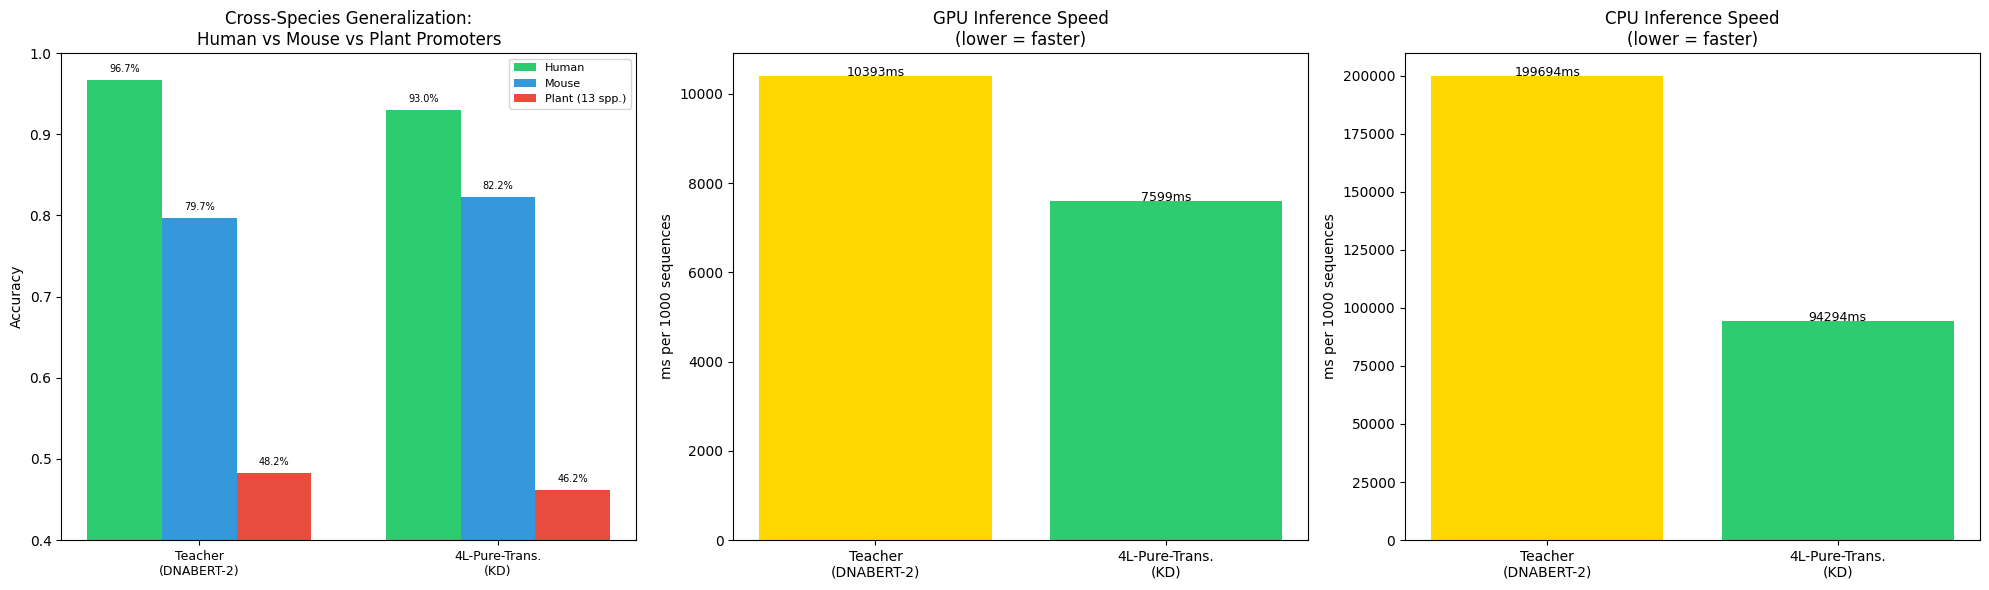

Charts saved to /kaggle/working/pure_arch_generalization_speed.png
Results saved to /kaggle/working/pure_arch_generalization_speed.json

FINAL SUMMARY: 4L-Pure-Transformer (KD) vs DNABERT-2 Teacher
  Compression: 117.1M -> 32.5M (3.60x smaller)
  Human Acc:   96.71% -> 93.01% (drop: 3.70%)
  Mouse Acc:   79.66% -> 82.24%
  Plant Acc:   48.22% -> 46.20%
  GPU Speed:   10393ms -> 7599ms (1.37x faster)
  CPU Speed:   199694ms -> 94294ms (2.12x faster)


In [7]:
import matplotlib.pyplot as plt

# ===== CHART 1: Human vs Mouse vs Plant Accuracy =====
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

model_names_short = ["Teacher\n(DNABERT-2)", "4L-Pure-Trans.\n(KD)"]
model_keys = ["Teacher (DNABERT-2)", "4L-Pure-Transformer (KD)"]
human_acc_vals = [human_accs[k] for k in model_keys]
mouse_acc_vals = [mouse_results[k]["accuracy"] for k in model_keys]
plant_acc_vals = [plant_results[k]["accuracy"] for k in model_keys]

x = np.arange(len(model_names_short))
width = 0.25

bars1 = axes[0].bar(x - width, human_acc_vals, width, label="Human", color="#2ecc71")
bars2 = axes[0].bar(x, mouse_acc_vals, width, label="Mouse", color="#3498db")
bars3 = axes[0].bar(x + width, plant_acc_vals, width, label="Plant (13 spp.)", color="#e74c3c")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Cross-Species Generalization:\nHuman vs Mouse vs Plant Promoters")
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names_short, fontsize=9)
axes[0].legend(fontsize=8)
axes[0].set_ylim(0.4, 1.0)
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f"{bar.get_height():.1%}", ha="center", fontsize=7)

# ===== CHART 2: GPU Speed =====
gpu_vals = [gpu_results[k] for k in model_keys]
colors = ["gold", "#2ecc71"]
bars4 = axes[1].bar(model_names_short, gpu_vals, color=colors)
axes[1].set_ylabel("ms per 1000 sequences")
axes[1].set_title("GPU Inference Speed\n(lower = faster)")
for bar, ms in zip(bars4, gpu_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f"{ms:.0f}ms", ha="center", fontsize=9)

# ===== CHART 3: CPU Speed =====
cpu_vals = [cpu_results[k] for k in model_keys]
bars5 = axes[2].bar(model_names_short, cpu_vals, color=colors)
axes[2].set_ylabel("ms per 1000 sequences")
axes[2].set_title("CPU Inference Speed\n(lower = faster)")
for bar, ms in zip(bars5, cpu_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"{ms:.0f}ms", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("/kaggle/working/pure_arch_generalization_speed.png", dpi=150, bbox_inches="tight")
plt.show()
print("Charts saved to /kaggle/working/pure_arch_generalization_speed.png")

# ===== SAVE ALL RESULTS AS JSON =====
all_results = {
    "human_accuracy": {k: float(v) for k, v in human_accs.items()},
    "mouse_results": {k: {mk: float(mv) for mk, mv in v.items()} for k, v in mouse_results.items()},
    "plant_results": {k: {mk: float(mv) for mk, mv in v.items()} for k, v in plant_results.items()},
    "mouse_dataset_info": {
        "source": "DeePromoter (Oubounyt et al., 2019) via CNNPromoterData GitHub",
        "tata_promoters": len(mouse_tata),
        "nontata_promoters": len(mouse_nontata),
        "non_promoters": len(mouse_nonprom),
        "total": len(mouse_sequences),
    },
    "plant_dataset_info": {
        "source": "zhangtaolab/plant-multi-species-core-promoters (HuggingFace)",
        "total_test": len(plant_test),
        "species": dict(species_counts),
    },
    "speed_benchmark": {
        "num_sequences": n_bench,
        "batch_size": 16,
        "gpu_ms_per_1000": {k: float(v) for k, v in gpu_results.items()},
        "cpu_ms_per_1000": {k: float(v) for k, v in cpu_results.items()},
        "gpu_speedup": {k: float(teacher_gpu_ms / gpu_results[k]) for k in gpu_results},
        "cpu_speedup": {k: float(teacher_cpu_ms / cpu_results[k]) for k in cpu_results},
    },
    "model_size": {
        "Teacher (DNABERT-2)": {"params": teacher_params, "params_M": round(teacher_params/1e6, 1)},
        "4L-Pure-Transformer (KD)": {"params": student_params, "params_M": round(student_params/1e6, 1)},
        "compression_ratio": round(teacher_params / student_params, 2),
    },
}

with open("/kaggle/working/pure_arch_generalization_speed.json", "w") as f:
    json.dump(all_results, f, indent=2)
print("Results saved to /kaggle/working/pure_arch_generalization_speed.json")

# ===== FINAL SUMMARY =====
print(f"\n{'='*80}")
print("FINAL SUMMARY: 4L-Pure-Transformer (KD) vs DNABERT-2 Teacher")
print(f"{'='*80}")
print(f"  Compression: {teacher_params/1e6:.1f}M -> {student_params/1e6:.1f}M ({teacher_params/student_params:.2f}x smaller)")
print(f"  Human Acc:   {human_accs['Teacher (DNABERT-2)']:.2%} -> {human_accs['4L-Pure-Transformer (KD)']:.2%} (drop: {human_accs['Teacher (DNABERT-2)'] - human_accs['4L-Pure-Transformer (KD)']:.2%})")
print(f"  Mouse Acc:   {mouse_results['Teacher (DNABERT-2)']['accuracy']:.2%} -> {mouse_results['4L-Pure-Transformer (KD)']['accuracy']:.2%}")
print(f"  Plant Acc:   {plant_results['Teacher (DNABERT-2)']['accuracy']:.2%} -> {plant_results['4L-Pure-Transformer (KD)']['accuracy']:.2%}")
print(f"  GPU Speed:   {gpu_results['Teacher (DNABERT-2)']:.0f}ms -> {gpu_results['4L-Pure-Transformer (KD)']:.0f}ms ({teacher_gpu_ms/gpu_results['4L-Pure-Transformer (KD)']:.2f}x faster)")
print(f"  CPU Speed:   {cpu_results['Teacher (DNABERT-2)']:.0f}ms -> {cpu_results['4L-Pure-Transformer (KD)']:.0f}ms ({teacher_cpu_ms/cpu_results['4L-Pure-Transformer (KD)']:.2f}x faster)")
print(f"{'='*80}")